# 3. Evaluate Model

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)

In [3]:
np.random.seed(12049)

In [4]:
def get_classes(data_path, classes, data):
    print(f"---- {data} ----")
    knee_severity = {}
    count = 0

    for i in range(len(classes)):
        imgs = os.listdir(os.path.join(data_path, str(i)))
        knee_severity[i] = imgs
        count += len(imgs)

    for k, v in knee_severity.items():
        print(
            f"Grade {k} - {classes[k]}: {len(v)} images, {round((len(v) * 100) / count, 2)}%"
        )

    return knee_severity


def compute_confusion_matrix(
    predictions, valid_generator, class_names, model_name
):
    cm = confusion_matrix(
        y_true=valid_generator.labels,
        y_pred=np.argmax(predictions, axis=1),
    )

    cmn = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cmn,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show(block=False)


def get_metrics(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print(f"Accuracy Score - {model_name}: {acc:.2f}")
    print(f"Balanced Accuracy Score - {model_name}: {bal_acc:.2f}")
    print("\n")

    print(classification_report(y_test, y_pred))


def make_gradcam_heatmap(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        superimposed_img
    )

    return superimposed_img


## Load data

In [5]:
base_dir = "/content/drive/MyDrive/dataset/"
test_path = os.path.join(base_dir, 'test')

class_names = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

tests_data = get_classes(test_path, class_names, 'test')

---- test ----
Grade 0 - Healthy: 454 images, 29.95%
Grade 1 - Doubtful: 298 images, 19.66%
Grade 2 - Minimal: 431 images, 28.43%
Grade 3 - Moderate: 233 images, 15.37%
Grade 4 - Severe: 100 images, 6.6%


## Image data generator

In [6]:
model_name = "inception_resnet_v3"
batch_size = 256
target_size = (224, 224)

In [7]:
aug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.inception_v3.preprocess_input,
    horizontal_flip=True,
    brightness_range=[0.3, 0.8],
    width_shift_range=[-50, 0, 50, 30, -30],
    zoom_range=0.1,
    fill_mode="nearest",
)

noaug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.inception_v3.preprocess_input
)


In [8]:
test_generator = noaug_datagen.flow_from_directory(
    test_path,
    batch_size=batch_size,
    class_mode="categorical",
    target_size=target_size,
    shuffle=False,
)

Found 1516 images belonging to 5 classes.


In [9]:
y_test = test_generator.labels

## Load model

In [10]:
inv3 = tf.keras.models.load_model('/content/drive/MyDrive/inceptionRv3ffff.hdf5')

## Test data

In [11]:
predictions_inv3 = inv3.predict(test_generator)
score_inv3 = inv3.evaluate(test_generator, verbose=1)
print('Test loss:', score_inv3[0])
print('Test acc:', score_inv3[1])

6/6 [==============================] - 8s 1s/step - loss: 0.5043 - accuracy: 0.7718
Test loss: 0.504267692565918
Test acc: 0.771767795085907


## Metrics

In [12]:
get_metrics(
    test_generator.labels,
    y_pred=np.argmax(predictions_inv3, axis=1),
    model_name=model_name,
)

Accuracy Score - inception_resnet_v3: 0.77
Balanced Accuracy Score - inception_resnet_v3: 0.79


              precision    recall  f1-score   support

           0       0.69      0.99      0.81       454
           1       0.47      0.36      0.41       298
           2       0.96      0.71      0.81       431
           3       0.99      0.90      0.94       233
           4       0.93      1.00      0.97       100

    accuracy                           0.77      1516
   macro avg       0.81      0.79      0.79      1516
weighted avg       0.79      0.77      0.76      1516



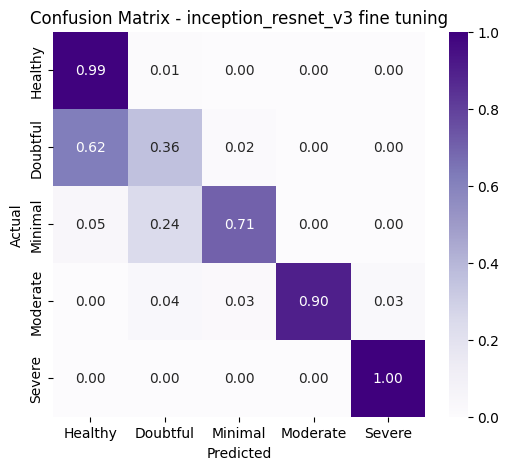

In [13]:
compute_confusion_matrix(
    predictions_inv3,
    test_generator,
    class_names,
    f"{model_name} fine tuning",
)

## Results

### Grad-Cam

In [14]:
inv3.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 5)                 10245     
                                                                 
Total params: 21,813,029
Trainable params: 21,778,597
Non-trainable params: 34,432
_________________________________________________________________


In [16]:
# Last layer
conv_output = inv3.get_layer("global_average_pooling2d").input

grad_model = tf.keras.models.Model(
    [inv3.inputs], [conv_output, inv3.output]
)

# model
inv3.layers[-1].activation = None

Test data - Healthy


<ipython-input-4-24d0ce795dd4>:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet")


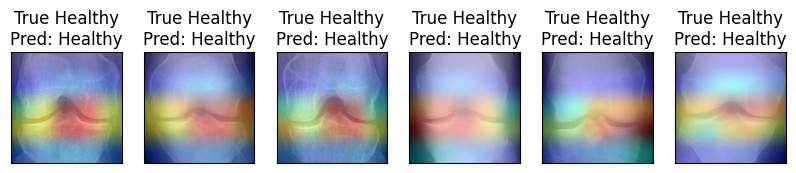

Test data - Doubtful


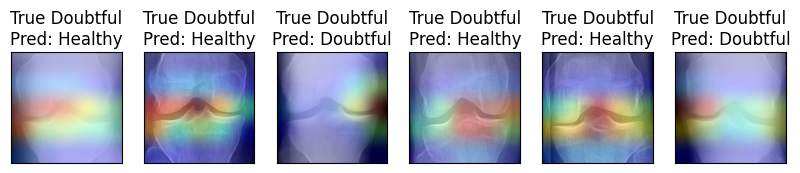

Test data - Minimal


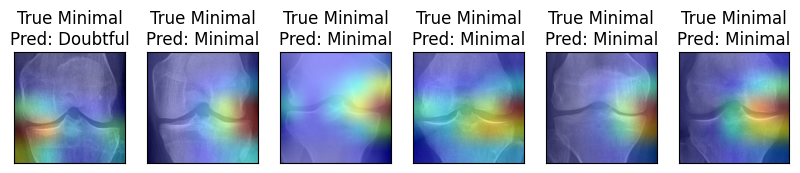

Test data - Moderate


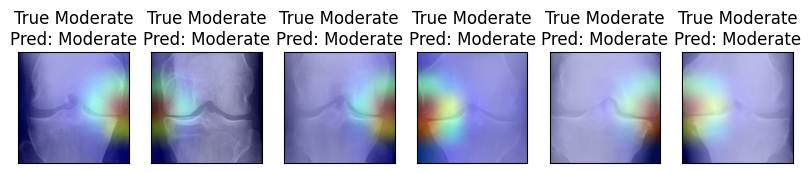

Test data - Severe


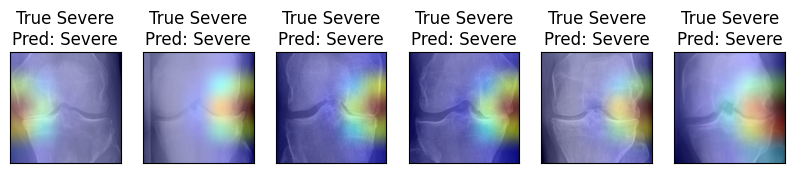

In [17]:
for k, v in tests_data.items():
    print(f"Test data - {class_names[k]}")
    plt.figure(figsize=(10, 28))
    for i in range(6):
        img_path = os.path.join(test_path, str(k), v[i])
        # prepare image
        img = tf.keras.preprocessing.image.load_img(
            img_path, target_size=target_size
        )
        img = tf.keras.preprocessing.image.img_to_array(img)

        img_aux = img.copy()
        img_array = np.expand_dims(img_aux, axis=0)
        img_array = np.float32(img_array)
        img_array = tf.keras.applications.inception_v3.preprocess_input(img_array)

        y_pred = inv3.predict(img_array, verbose=0)[0]

        heatmap = make_gradcam_heatmap(grad_model, img_array)
        image = save_and_display_gradcam(img, heatmap)

        plt.subplot(1, 6, 1 + i, xticks=[], yticks=[])
        plt.imshow(image)
        plt.title(
            f"True {class_names[k]}\nPred: {class_names[np.argmax(y_pred)]}"
        )
        # plt.xlabel(
        #     "\n".join([f"{c} = {p:.2f}" for c, p in zip(class_names, y_pred)])
        
    plt.show() 